<a href="https://colab.research.google.com/github/kithik7/Theoretical_Neuroscience/blob/Ex5_Rescorla_Wagner/TNS_II_Exercise_5_Rescorla_Wagner_Solvef_k7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In classical conditioning, an animal experiences a series of discrete trials comprising both stimuli and rewards.  Based on this experience, the animal forms an *expectation* for potential future rewards.  Sometimes, this expectation manifests itself in overt behaviour (e.g., salivation, licking). The Rescorla-Wagner rule offers a concise account of many classical conditioning experiments (not all).  You will implement and evaluate the RW rule for situations in which two stimuli are independently present or absent.

For the visualisation of trial sequences, function `ShowSequence()` is provided.

## Two independent stimuli


Consider two stimuli, $A$ and $B$, which are independently present, with probabilities $p_A$ and $p_B$, respectively, or absent, with probabilities $1-p_A$ and $1-p_B$, respectively.   The table of joint probabilities is

\begin{array}{c|cc|c}
 & A & \neg A &  \\
 \hline
 B & p_A\,p_B & (1-p_A)\, p_B& p_B\\
 \neg B & p_A\,(1-p_B) & (1-p_A)\, (1-p_B) & 1- p_B \\
 \hline
 & p_A & 1-p_A&  1 \\
\end{array}

The stimuli of any given trial are represented by a two-element vector ${\bf u} = (u_A, u_B)$.  Its elements $u_{A,B}$ assume values of $0$ or $1$, indicating presence or absence of $A$ (first element) and $B$ (second element).

\\

Note that ${\bf u}$ is a random variable for which we may define an expectation
 $\langle{ f( {\bf u})\rangle}$.  You are going to need the expectation $\langle{\bf u}\rangle  $, the cross-correlation matrix $\langle{ \bf u \, \bf u} \rangle = \left( \begin{array}{cc} \langle{u_1^2}\rangle & \langle{u_1 \, u_2} \rangle \\ \langle{u_1 \, u_2} \rangle & \langle{u_2^2}\rangle\end{array}\right)$, and its inverse matrix $\langle{ \bf u \, \bf u \rangle}^{-1}$.  

\\

Complete the probability table for the special case of $p_A = 1/3$ and $p_B = 1/5$! Compute the expectations $\langle{\bf u} \rangle $, $\langle{ \bf u \, \bf u} \rangle$ and $ \langle{ \bf u \, \bf u}\rangle^{-1}$ for  $p_A =1/3$ and $p_B = 1/5$!

## Full conditioning

Assuming that a reward $r=1$ is received whenever $A$ is present (regardless of $B$), the probability table for reward probability $p_r$ is

\begin{array}{c|cc|c}
 p_r & A & \neg A &  \\
 \hline
 B & p_A\,p_B & 0 & p_A \, p_B\\
 \neg B & p_A\,(1-p_B) & 0 & p_A\,(1- p_B) \\
 \hline
 & p_A & 0 &  p_A \\
\end{array}

NB: This is no longer a simple joint probability distribution as it doesn't sum to 1. Instead, we multiplied all values in the first table by the reward values.

Compute the joint probability of reward and stimulus $\langle r \ \textbf{u} \rangle $ the conditional probability of reward, given a stimulus
$\langle r | \textbf{u} \rangle $ and the specific reward expectation, as predicted by the Rescorla-Wanger rule:

$$
\textbf{w}_{ss} =  \langle\textbf{u} \, \textbf{u}\rangle^{-1} \cdot \langle r \, \textbf{u}\rangle
$$

Apply the Rescorla-Wagner rule to iteratively learn specific reward expectations! To this end, generate 100 stimulus vectors $\textbf{u}_i$ as well as the associated rewards $r_i$
! Starting from $\textbf{w}_0 = \left( \begin{array}{c} 0 \\  0 \end{array} \right) $, compute for each trial i the prediction error

$$
\delta_i = r_i - \textbf{w}_{i-1} \cdot \textbf{u}_i
$$
and increment the reward expectations
$$
w_{i} = w_{i-1} + \epsilon \, \textbf{u}_i \, \delta_i
$$
where $\epsilon = 0.05$ is a learning rate!  Finally, plot the development of reward expectations $w_{1,2}$ over time and convince yourself that they converge to the predicted values! Do reward expectations converge to the predicted values $\textbf{w}_{ss}$? Are $\langle r | \textbf{u} \rangle $ and $\textbf{w}_{ss}$ identical?

## Partial conditioning

Assuming that a reward $r=1$ is received with probability $p_r=1/2$ whenever $A$ is present (regardless of $B$), apply the RW rule once more to iteratively learn specific reward expectations!   As before, generate stimulus vectors and associated rewards and increment the reward expectations after each trial!


Plot the development and show that reward expectations approach $\textbf{w} \to \left(\begin{array}{c} 1/2 \\ 0 \end{array} \right)$ !


## Inhibitory conditioning

Assuming that a reward $r=1$ is received with probability $p_r=1$ whenever $A$ is present *and* $B$ is absent (but never otherwise), apply the RW rule to iteratively learn specific reward expectations!   As before, generate stimulus vectors and associated rewards and increment the reward expectations after each trial!


Plot the development and show that reward expectations approach $\textbf{w} \to \left(\begin{array}{c} 6/7 \\ -2/7 \end{array} \right)$ !

Explain why reward expectations are partially negative!




# Rescorla-Wagner rule

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def show_sequence(U, R, D, W):
    N, Ntrials = U.shape

    # Define patch coordinates for squares
    xi = np.array([-0.05, -0.05, 0.05, 0.05])
    yi = np.array([-0.25, 0.25, 0.25, -0.25])

    # Define colours
    clr = np.array([[1, 0, 0], [0, 0, 1], [0, 1, 0], [0.8, 0.8, 0]])

    fig, axes = plt.subplots(2, 1, figsize=(10, 6))

    # First subplot: Stimuli and Reward
    ax1 = axes[0]
    ax1.set_title('Stimuli and Reward')
    for c in range(N):
        kk = np.where(U[c, :] == 1)[0]
        for i in kk:
            ax1.fill(i + xi, c + 1 + yi, color=clr[c, :])

    kk = np.where(R[0, :] > 0)[0]
    for i in kk:
        ax1.fill(i + xi, N + 1 + yi, color=clr[2, :] * R[0, i])

    ax1.set_xlim([0, Ntrials + 1])
    ax1.set_ylim([0, N + 2])
    ax1.set_ylabel('Stimuli, Reward')
    ax1.set_xlabel('Trials')

    # Second subplot: Weights and Delta
    ax2 = axes[1]
    ax2.set_title('Weights and Delta')
    mn = min(D.min(), W.min())
    mx = max(D.max(), W.max())

    for c in range(N):
        ax2.plot(range(1, Ntrials + 1), W[c, :], linestyle=':', color=clr[c, :], linewidth=2.0)

    ax2.scatter(range(1, len(D)+1), D, marker='o', facecolors='none', edgecolors='k', linewidth=1.2)

    ax2.set_xlim([0, Ntrials + 1])
    ax2.set_ylim([mn, mx])
    ax2.set_ylabel('Weights, Delta')
    ax2.set_xlabel('Trials')

    plt.tight_layout()
    plt.show()


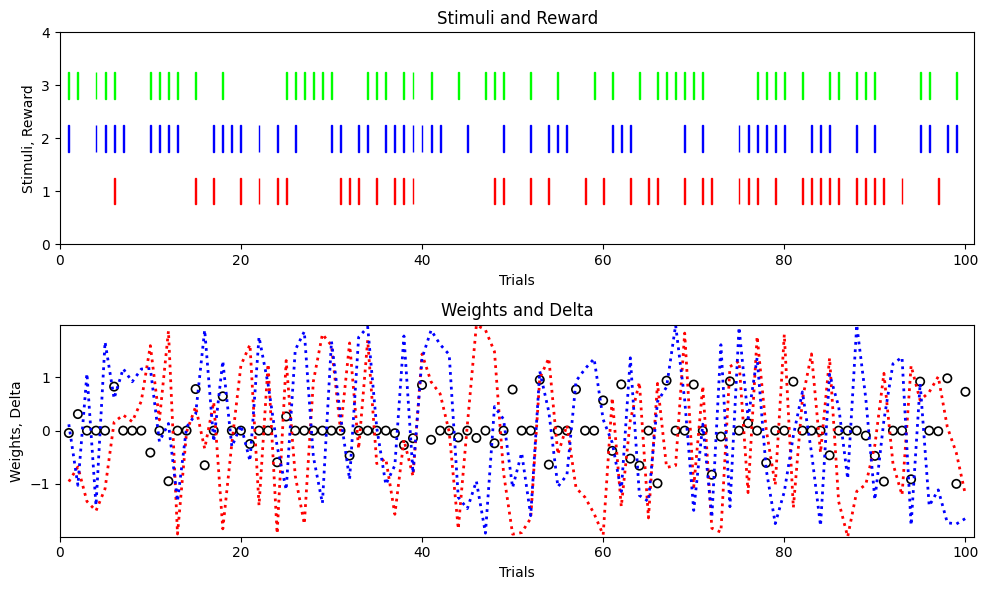

In [ ]:
# Generate some random sample data
N = 2
Ntrials = 100

U = np.random.choice([0, 1], size=(N, Ntrials))
R = np.random.choice([0, 1], size=(1, Ntrials))
D = np.random.uniform(-1, 1, size=Ntrials) * np.random.choice([0, 1], size=Ntrials)
W = np.random.uniform(-2, 2, size=(N, Ntrials))
show_sequence(U, R, D, W)


Task 2 - Full Conditioning: w_ss = [ 1.0000000e+00 -1.7182023e-17]
Task 3 - partial Conditioning: w_ss = [ 5.0000000e-01 -8.5910115e-18]
Task 4 - Inhibitory Conditioning: w_ss = [ 0.85714286 -0.28571429]


'\nstim a is red, blue is stim B, reward is green\nin task 1 weights and delta full conditioning w\n\nstim a is rising towards 1, w_B is staying near 0, green reward bars appear when red appears, not tallied with blue\ndelta circles are large early and shrink later, there are three bands of delta circles because there are three distinct situations that produce different prediction errors \ntop band is positive - trials where r arrived but was not fully predicted, r =1, v is small, so delta r-v is positive and large \n\nmiddle band near 0 is where no r arrived and none was predicted, r = 0, v is near 0 so delta is almost 0, trials where neither or only B appeared \nbottom band (negative, around -0.5) trials where no reward arrived but the brain predicted some. r=0, v is positive (a or b was present) and v is prediction so delta r-v \nis negative \n\nas learning progress, top and bottom bands should move towards 0, early trials it reaches 1 and later it clusters around 0.5, so partial co

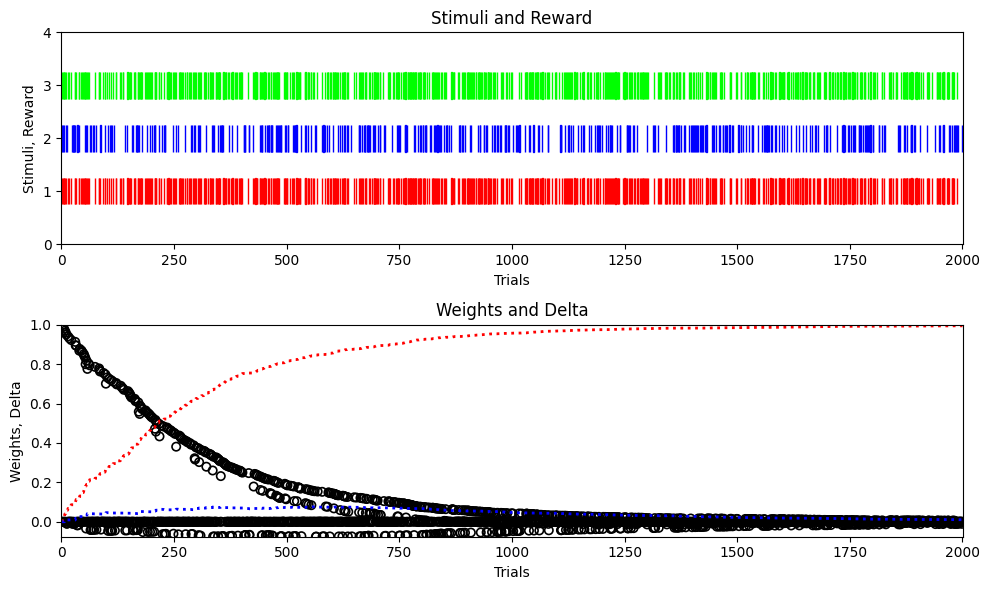

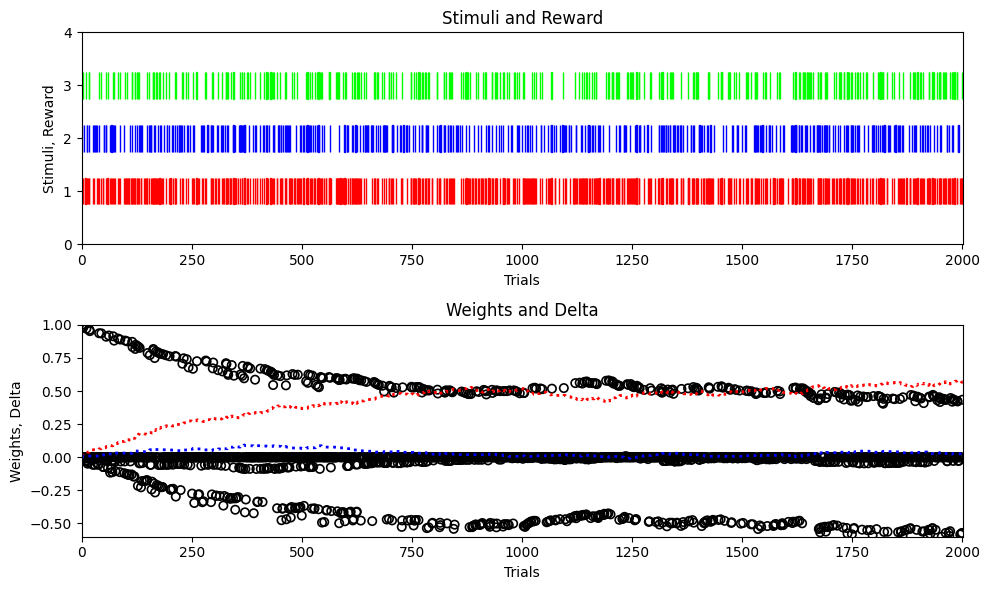

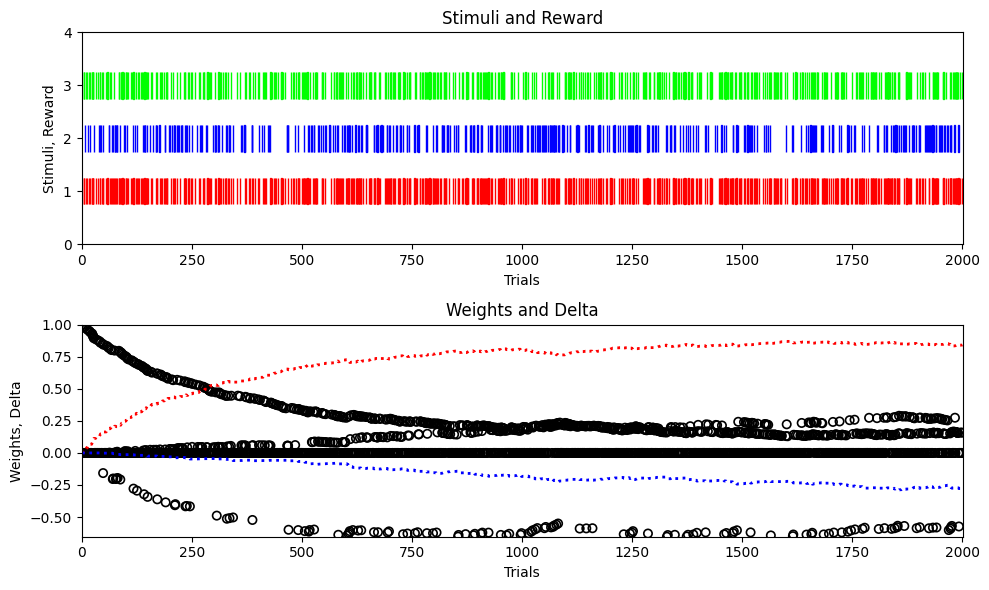

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ShowSequence function
def show_sequence(U, R, D, W):
    N, Ntrials = U.shape
    xi = np.array([-0.05, -0.05, 0.05, 0.05]) #dimensions of small rectangles for stimuli nreward tally plot
    yi = np.array([-0.25, 0.25, 0.25, -0.25])
    clr = np.array([[1, 0, 0], [0, 0, 1], [0, 1, 0], [0.8, 0.8, 0]]) #color assignment for a = red, b = blue, reward = green
    fig, axes = plt.subplots(2, 1, figsize=(10, 6))
    ax1 = axes[0]
    ax1.set_title('Stimuli and Reward')
    for c in range(N):  #C is the index of current stim if c = 0 then its stim a , c = 1 is stim b
        kk = np.where(U[c, :] == 1)[0] #[0]array is stored as tuple, so one single element is the array, [0] unpacks it
        for i in kk:
            ax1.fill(i + xi, c + 1 + yi, color=clr[c, :]) #number i stimulus row c+1, xi and yi are corner offsets and clr assigns appropriate stim
    kk = np.where(R[0, :] > 0)[0]
    for i in kk:
        ax1.fill(i + xi, N + 1 + yi, color=clr[2, :] * R[0, i])
    ax1.set_xlim([0, Ntrials + 1])
    ax1.set_ylim([0, N + 2])
    ax1.set_ylabel('Stimuli, Reward')
    ax1.set_xlabel('Trials')
    ax2 = axes[1]
    ax2.set_title('Weights and Delta')
    mn = min(D.min(), W.min())
    mx = max(D.max(), W.max()) #max and min for y axis scaling
    for c in range(N):
        ax2.plot(range(1, Ntrials + 1), W[c, :], linestyle=':', color=clr[c, :], linewidth=2.0) #wa and wb plotted
    ax2.scatter(range(1, len(D)+1), D, marker='o', facecolors='none', edgecolors='k', linewidth=1.2) #delta circles
    ax2.set_xlim([0, Ntrials + 1])
    ax2.set_ylim([mn, mx])
    ax2.set_ylabel('Weights, Delta')
    ax2.set_xlabel('Trials')
    plt.tight_layout()

# Parameters
p_A = 1/3
p_B = 1/5
epsilon = 0.01 #0.05 convergence wasnt so clear
n_trials = 2000 #at 100, barely

# Analytical section
C = np.array([[p_A, p_A * p_B],
              [p_A * p_B, p_B]])
#analytical cross correlation matrix as a result of u * u transpose
C_inv = np.linalg.inv(C) #inverted c because <r*u> = w_ss * C , solve for w_ss, cannot divide by a matrix, its equivalent is inversion

ru_task2 = np.array([p_A, p_A * p_B])  #ru is the learning rule ie cooccurence of reward and task , for task 2 ruA = p_A r comes when A is present, ru_b is joint
#probability of a and b because r = 1 only when stim appears so a must be present for both reward and b to happen simultaneously - b occurs independently
ru_task3 = np.array([p_A * 0.5, p_A * 0.5 * p_B]) #r = 1 when stim probability is less than half and if uA == 1 else its 0
ru_task4 = np.array([p_A * (1 - p_B), 0]) #r = 1 only when a==1 and b==0

w_ss_task2 = np.dot(C_inv, ru_task2)
w_ss_task3 = np.dot(C_inv, ru_task3)
w_ss_task4 = np.dot(C_inv, ru_task4)

#flow for for loops
"""
first set parameters and weight initialised to 0.0, 0.0
step 2 make containers for the 4 inputs that show sequence function requires, URDW and their shapes, using np.zeros for placeholder container of this size
so u is 2 rows and 100 trials, r is 1 row for 100 trials, d is just values ie a line of entries no rows or columns and w is 2 weight rows across 100 trials

for trial in range (number of trials)
define u_A = 1 if np.random.rand() ie empty random number between 0 and 1 is less than p_A (0.333) so think of the darts falling in this zone between 0 and 0.333
define u_B = 1 if np.random.rand() ie empty random number between 0 and 1 is less than p_B (0.25) so think of the darts falling in this zone between 0 and 0.25
and a number falling in either zone means it falls in there the proportion is exactly 1/3 of them that are less than 0.333, 0-0.333 is the zone size, and because
the number falls or lands uniformly (equally likely anywhere), the fraction of line a zone covers = fraction of times the dart lands there therefore u_a or u_b = their probabilities
being 1

then store u_A and u_B as a numpy array cause its easier
then compute v = dot product of w x u because w and u are vectors and v first because prediction arrives before reward
then compute delta which is r-v
then update w which w + epsilon (learning rate) scaled by delta scaled by u
then store them in your containers
alternatively you could assign a w_history container and say w_history.append(w.copy()) which would snapshot each weight for a moment in time and freezes it and then collects it in
w_history = np.array(w_history)
and then you would plot manually for each loop




show_sequence(U_store, R_store, D_store, W_store) is a different approach

the only difference between all 3 loops is the learning rule so it is very very straightforward


"""

# Task 2 Full Conditioning
w = np.array([0.0, 0.0])
U_store = np.zeros((2, n_trials))
R_store = np.zeros((1, n_trials))
D_store = np.zeros(n_trials)
W_store = np.zeros((2, n_trials))

for t in range(n_trials):
    u_A = 1 if np.random.rand() < p_A else 0
    u_B = 1 if np.random.rand() < p_B else 0
    u = np.array([u_A, u_B])
    r = 1 if u_A == 1 else 0
    v = np.dot(w, u)
    delta = r - v
    w = w + epsilon * delta * u
    U_store[:, t] = u
    R_store[0, t] = r
    D_store[t] = delta
    W_store[:, t] = w

show_sequence(U_store, R_store, D_store, W_store)
print('Task 2 - Full Conditioning: w_ss =', w_ss_task2)
plt.savefig('task2.png')


# Task 3 Partial Conditioning
w = np.array([0.0, 0.0])
U_store = np.zeros((2, n_trials))
R_store = np.zeros((1, n_trials))
D_store = np.zeros(n_trials)
W_store = np.zeros((2, n_trials))

for t in range(n_trials):
    u_A = 1 if np.random.rand() < p_A else 0
    u_B = 1 if np.random.rand() < p_B else 0
    u = np.array([u_A, u_B])
    r = (1 if np.random.rand() < 0.5 else 0) if u_A == 1 else 0
    v = np.dot(w, u)
    delta = r - v
    w = w + epsilon * delta * u
    U_store[:, t] = u
    R_store[0, t] = r
    D_store[t] = delta
    W_store[:, t] = w

show_sequence(U_store, R_store, D_store, W_store)
print('Task 3 - partial Conditioning: w_ss =', w_ss_task3)
plt.savefig('task3.png')

# Task 4 Inhibitory Conditioning
w = np.array([0.0, 0.0])
U_store = np.zeros((2, n_trials))
R_store = np.zeros((1, n_trials))
D_store = np.zeros(n_trials)
W_store = np.zeros((2, n_trials))

for t in range(n_trials):
    u_A = 1 if np.random.rand() < p_A else 0
    u_B = 1 if np.random.rand() < p_B else 0
    u = np.array([u_A, u_B])
    r = 1 if u_A == 1 and u_B == 0 else 0
    v = np.dot(w, u)
    delta = r - v
    w = w + epsilon * delta * u
    U_store[:, t] = u
    R_store[0, t] = r
    D_store[t] = delta
    W_store[:, t] = w

show_sequence(U_store, R_store, D_store, W_store)
print('Task 4 - Inhibitory Conditioning: w_ss =', w_ss_task4)

plt.savefig('task4.png')

"""

what the plots tell you:
stim a is red, blue is stim B, reward is green
in task 1 weights and delta full conditioning w

stim a is rising towards 1, w_B is staying near 0, green reward bars appear when red appears, not tallied with blue
delta circles are large early and shrink later, there are three bands of delta circles because there are three distinct situations that produce different prediction errors
top band is positive - trials where r arrived but was not fully predicted, r =1, v is small, so delta r-v is positive and large

middle band near 0 is where no r arrived and none was predicted, r = 0, v is near 0 so delta is almost 0, trials where neither or only B appeared
bottom band (negative, around -0.5) trials where no reward arrived but the brain predicted some. r=0, v is positive (a or b was present) and v is prediction so delta r-v
is negative

as learning progress, top and bottom bands should move towards 0, early trials it reaches 1 and later it clusters around 0.5, so partial convergence
with slarge epsilon and 2000 trials, 0.05 epsilon is too large for clean convergence, bottom band should not exist so much in task 2 full conditioning, it means sometimes
the brain predicted reward but it didnt arrive, this happens when b is present and wB got briefly pushed up and contributed to v, but reward didnt come because A was absent

when epsilon ws changed to 0.01 and trials = 2000, wA Rises smoothly towards 1, wb stays near 0, delta circles starting near 1 decay smoothly towards 0 in top band,and one clear
band of delta that converges after decay cause singular stim a = reward

for partial conditioning:
  w_A red hovering around 0.5 - as predicted,
  w_B blue near 0, three delta bands because reward is random even when A is present, creating more variance
  weights fluctuate more than task 2 - consequence of partial conditioning

for inhibitory conditioning
red rising but doesnt reach 6/7 yet and still goes up
wb is negative -2/7
two bands of delta positive when rewards arrives, negative when brain overpredicts
needs more trials to fully converge

"""